Importation des packages

In [33]:
import pandas as pd 
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import math

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler



from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity="all"
#ignore les warnings
#import warnings
#warnings.filterwarnings("ignore")

Importation de la base de données

In [2]:
path ="data//Raw_Data//Attrition_employes.xlsx"
Attrition_df = pd.read_excel(path)
Attrition_df.head()

,Age,Attrition,Voyage_affaires,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,Satisfaction_relationnelle,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1.0,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8.0,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2.0,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3.0,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2.0,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


#  Preprocessing

| **Fonctionnalité**                        | **Description**                                                                                                                                                    |
|-------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `Âge`                                     | L'âge de l'employé.                                                                                                                                              |
| `Attrition (colonne cible)`              | Indicateur indiquant si l'employé a quitté l'entreprise ou non.                                                                                                  |
| `Voyage_affaires`                        | Fréquence à laquelle l'employé a voyagé pour le compte de l'entreprise.                                                                                          |
| `DailyRate`                               | Montant que l'employé coûte à l'entreprise en tant que taux horaire.                                                                                            |
| `Département`                             | Dans quel département travaille l'employé.                                                                                                                      |
| `DistanceFromHome`                        | La distance entre le domicile de l'employé et le bureau.                                                                                                        |
| `Formation`                               | 1 « Inférieur au collège », 2 « Collège », 3 « Licence », 4 « Master », 5 « Docteur ».                                                                         |
| `EducationField`                          | Dans quelle industrie l'employé a une formation.                                                                                                               |
| `EmployeeCount`                           | Un nombre d'employés.                                                                                                                                           |
| `EmployeeNumber`                          | Un numéro d'identification unique attribué à chaque employé.                                                                                                     |
| `EnvironmentSatisfaction`                 | Indication de la satisfaction d'un employé avec son environnement sur une échelle de 1 à 4, 1 étant « Faible », 2 « Moyen », 3 « Élevé » et 4 « Très élevé ».    |
| `Genre`                                   | Le sexe de l'employé.                                                                                                                                           |
| `HourlyRate`                              | Montant qu'un employé gagne en taux horaire.                                                                                                                    |
| `Implication_dans_emploi`                | Degré d'implication d'un employé dans son travail sur une échelle de 1 à 5.                                                                                     |
| `JobLevel`                                | Indication du niveau de classement du poste d'un employé, allant de 1 à 5.                                                                                      |
| `JobRole`                                 | L'intitulé du poste de l'employé.                                                                                                                                 |
| `Satisfaction_travail`                   | Indication du degré de satisfaction d'un employé par rapport à son travail sur une échelle de 1 à 4.                                                              |
| `État_civil`                             | L'état de la relation de l'employé.                                                                                                                              |
| `Revenu_mensuel`                         | Combien gagne l'employé sur une base mensuelle.                                                                                                                |
| `MonthlyRate`                            | Combien l'employé coûte à l'entreprise en tant que taux mensuel.                                                                                                |
| `NumCompaniesWorked`                     | Nombre d'entreprises pour lesquelles l'employé a travaillé auparavant.                                                                                           |
| `Over18_Index`                           | Si l'employé a plus de 18 ans ou non.                                                                                                                           |
| `Heures_supplémentaires`                 | Si l'employé a effectué des heures supplémentaires ou non.                                                                                                       |
| `PercentSalaryHike`                      | Pourcentage d'augmentation de salaire de l'employé.                                                                                                            |
| `Évaluation_performance`                 | 1 « Faible », 2 « Bon », 3 « Excellent », 4 « Exceptionnel ».                                                                                                   |
| `Satisfaction_relationnelle`             | 1 « Faible », 2 « Moyen », 3 « Élevée », 4 « Très élevée ».                                                                                                     |
| `StandardHours`                           | Nombre d'heures que l'employé travaille habituellement sur 2 semaines.                                                                                          |
| `StockOptionLevel`                       | Quel niveau d'option d'achat d'actions l'employé a dans l'entreprise.                                                                                            |
| `TotalWorkingYears`                      | Depuis combien d'années l'employé a travaillé.                                                                                                                 |
| `TrainingTimesLastYear`                  | Combien de temps l'employé a passé en formation l'année dernière.                                                                                                |
| `WorkLifeBalance`                        | Indicateur de l'équilibre entre vie professionnelle et vie privée de l'employé.                                                                                |
| `YearsAtCompany`                         | Depuis combien d'années l'employé travaille dans l'entreprise.                                                                                                   |
| `YearsInCurrentRole`                     | Depuis combien d'années l'employé occupe son poste actuel.                                                                                                       |
| `YearsSinceLastPromotion`                | Depuis combien d'années se sont écoulées depuis la dernière promotion des employés.                                                                              |
| `YearsWithCurrManager`                   | Depuis combien d'années l'employé travaille avec son manager actuel.                                                                                             |

In [3]:

cible = [
    'Attrition'
]
quant_features = [
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'HourlyRate',
    'Revenu_mensuel',
    'MonthlyRate',
    'NumCompaniesWorked',
    'PercentSalaryHike',
    'TotalWorkingYears',
    'TrainingTimesLastYear',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

ordinal_var = [
    'Education','EnvironmentSatisfaction',
    'Implication_dans_emploi','JobLevel',
    'Satisfaction_travail','Évaluation_performance',
    'Satisfaction_relationnelle','StockOptionLevel',
    'WorkLifeBalance'
    ]

nominal_var = [
    'Voyage_affaires','Department',
    'EducationField','Genre',
    'JobRole','État_civil',
    'Heures_supplémentaires'
]
qual_var  =  cible+ ordinal_var + nominal_var

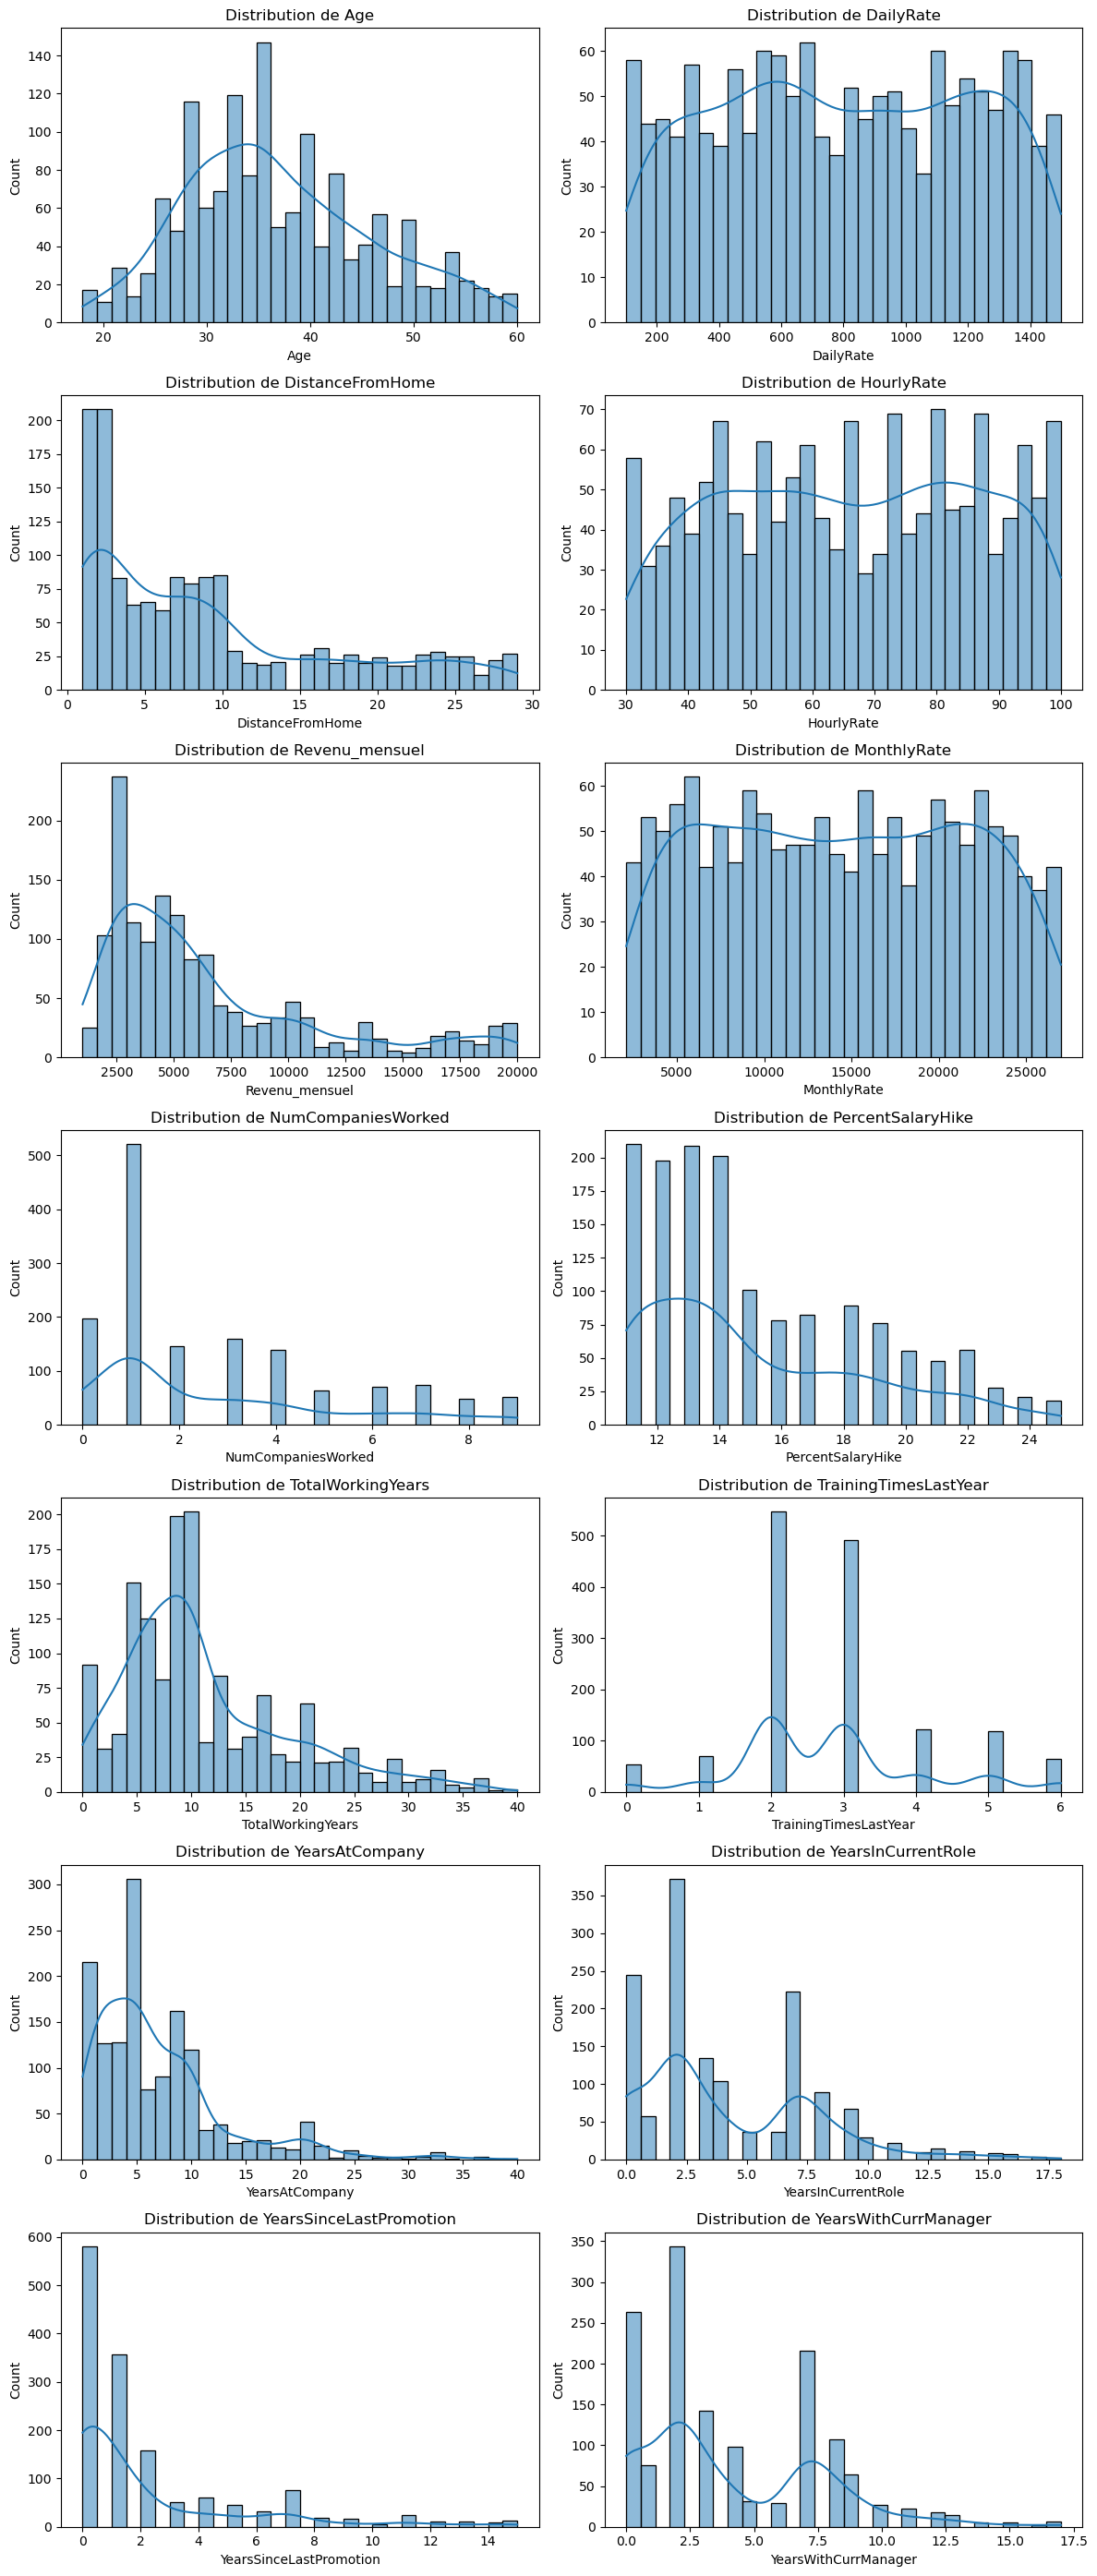

In [4]:
n = len(quant_features)
n_rows = math.ceil(n / 2)

fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))

# Aplatir la matrice des axes pour itérer facilement
axes = axes.flatten()
# Boucle sur les variables
for i, col in enumerate(quant_features):
    sns.histplot(
        Attrition_df[col],
        kde=True,
        ax=axes[i],
        bins=30
    )
    axes[i].set_title(f"Distribution de {col}")
# Supprimer les axes inutilisés (si nombre impair)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Valeurs abbérantes

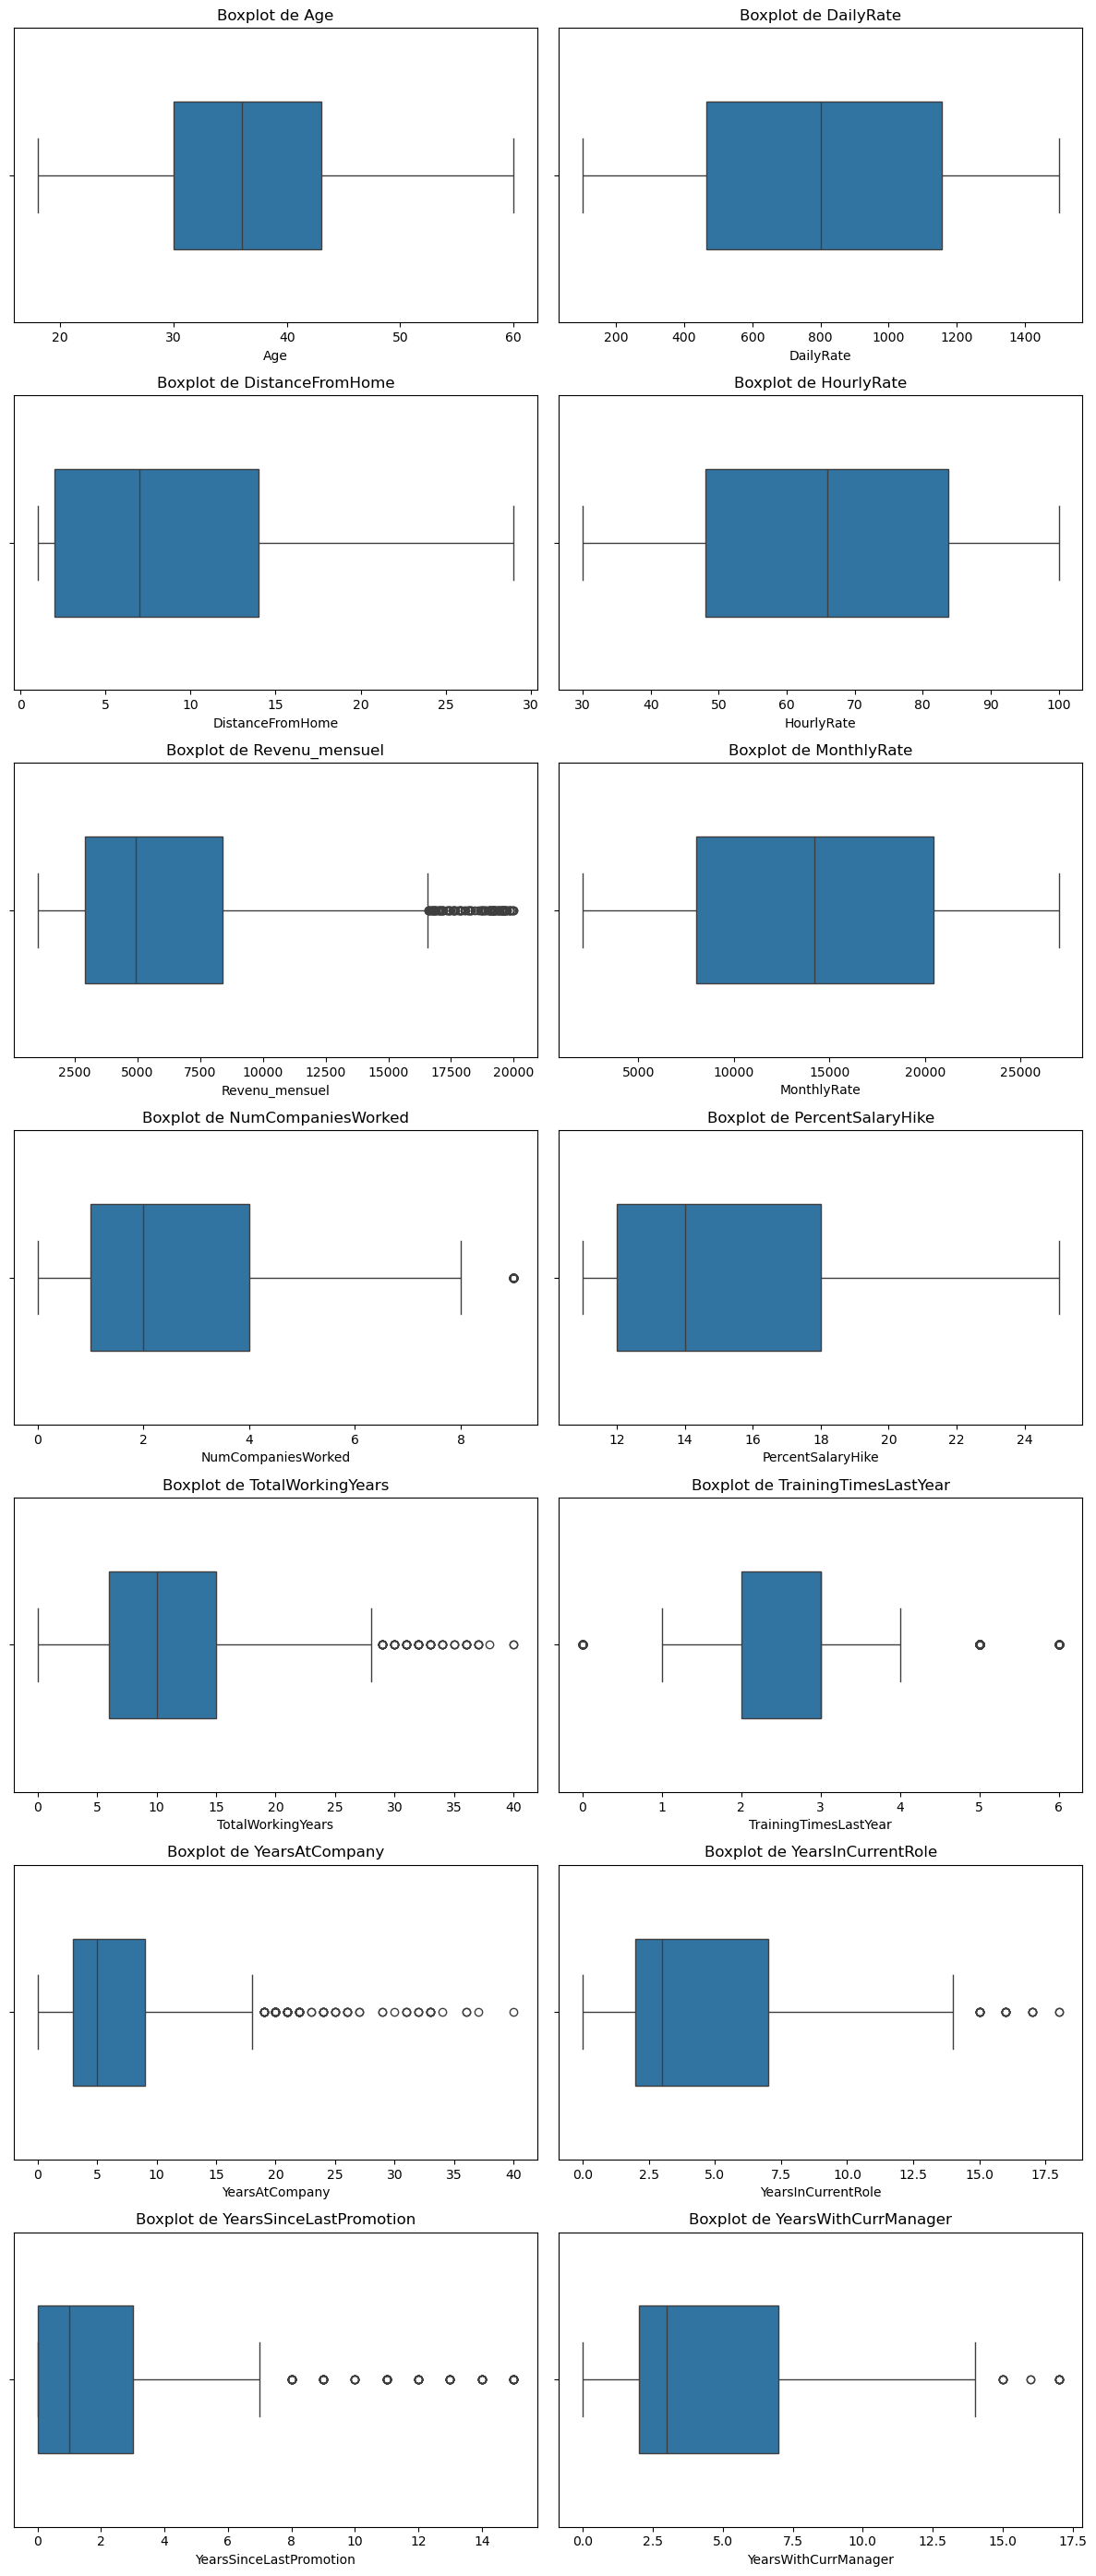

In [ ]:
n = len(quant_features)
n_rows = math.ceil(n / 2)

fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(quant_features):
    ax = axes[i]  
    _ = sns.boxplot(   
        x=Attrition_df[col],
        ax=ax,
        width=0.5,
        linewidth=1
    )

    _ = ax.set_title(f"Boxplot de {col}")  

# Supprimer axes inutiles
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [52]:
vars_outliers = []
for col in quant_features:
    
    # Calcul des quartiles
    Q1 = Attrition_df[col].quantile(0.25)
    Q3 = Attrition_df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Bornes des outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Détection des outliers
    outliers = Attrition_df[(Attrition_df[col] < lower_bound) | 
                            (Attrition_df[col] > upper_bound)]
    
    # Pourcentage d'outliers
    pct_outliers = len(outliers) / len(Attrition_df)

    # Condition > 10%
    if pct_outliers > 0.05:
        vars_outliers.append(col)

# Résultat
vars_outliers

['Revenu_mensuel',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsSinceLastPromotion']

Pour les variables : "Revenu_mensuel", "YearsSinceLastPromotion", "TrainingTimesLastYear", "YearsAtCompany", présentant des valeurs abbérantes, nous appliquons le logarithme.

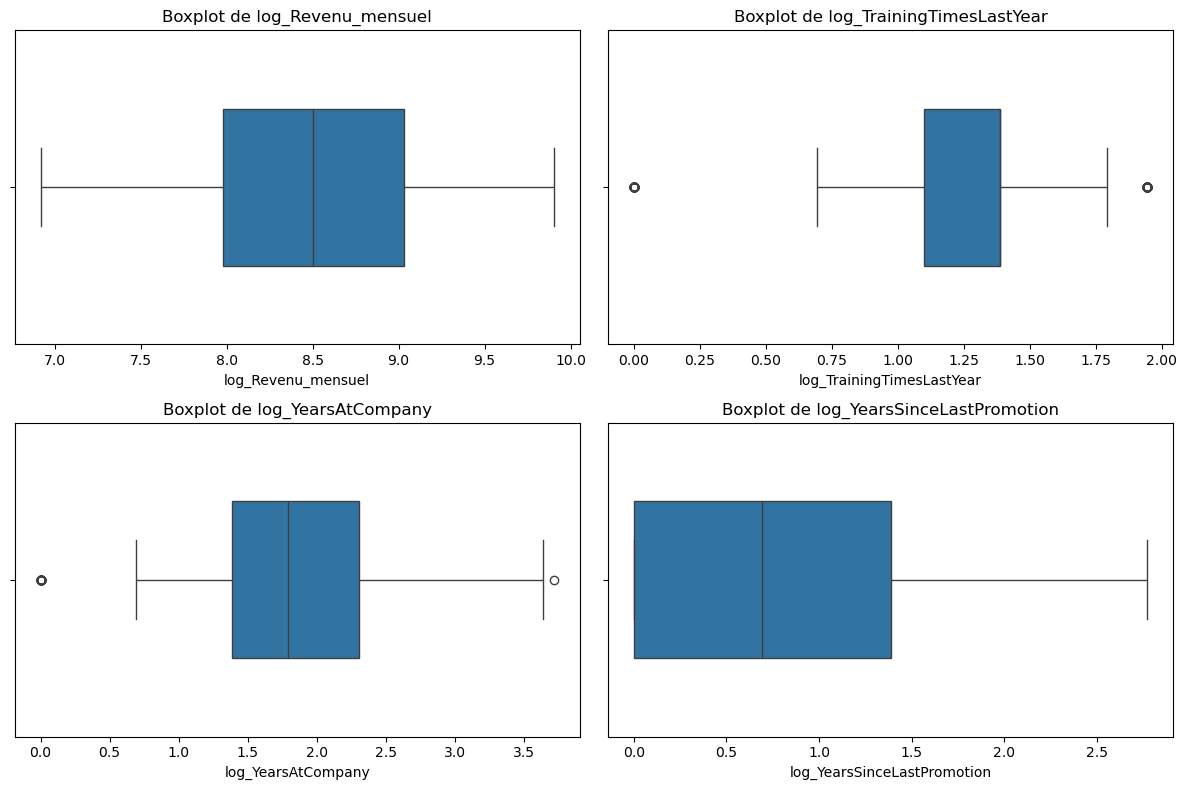

In [53]:
var_log = vars_outliers

data_Log = pd.DataFrame()

for col in var_log:
    data_Log[f"log_{col}"] = np.log1p(Attrition_df[col])

n = len(data_Log.columns)
n_rows = math.ceil(n / 2)

fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(data_Log.columns):
    ax = axes[i]

    _ = sns.boxplot(
        x=data_Log[col],
        ax=ax,
        width=0.5,
        linewidth=1
    )

    _ = ax.set_title(f"Boxplot de {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [5]:
Attrition_df_copy = Attrition_df.copy()
Attrition_df_copy = Attrition_df_copy.drop(columns=["EmployeeCount"])

In [6]:
Attrition_df.dtypes

Age                             int64
Attrition                      object
Voyage_affaires                object
DailyRate                       int64
Department                     object
DistanceFromHome              float64
Education                       int64
EducationField                 object
EmployeeCount                   int64
EmployeeNumber                  int64
EnvironmentSatisfaction         int64
Genre                          object
HourlyRate                      int64
Implication_dans_emploi         int64
JobLevel                        int64
JobRole                        object
Satisfaction_travail            int64
État_civil                     object
Revenu_mensuel                  int64
MonthlyRate                     int64
NumCompaniesWorked              int64
Over18_Index                   object
Heures_supplémentaires         object
PercentSalaryHike               int64
Évaluation_performance          int64
Satisfaction_relationnelle      int64
StandardHour

In [7]:
Attrition_df.isna().sum()

Age                            0
Attrition                      0
Voyage_affaires                0
DailyRate                      0
Department                     0
DistanceFromHome              16
Education                      0
EducationField                 0
EmployeeCount                  0
EmployeeNumber                 0
EnvironmentSatisfaction        0
Genre                          0
HourlyRate                     0
Implication_dans_emploi        0
JobLevel                       0
JobRole                        0
Satisfaction_travail           0
État_civil                     0
Revenu_mensuel                 0
MonthlyRate                    0
NumCompaniesWorked             0
Over18_Index                   0
Heures_supplémentaires         0
PercentSalaryHike              0
Évaluation_performance         0
Satisfaction_relationnelle     0
StandardHours                  0
StockOptionLevel               0
TotalWorkingYears              0
TrainingTimesLastYear          0
WorkLifeBa

Séparation des données en Train et Test

In [8]:

X = Attrition_df.drop(columns="Attrition")   
y = Attrition_df["Attrition"]                 

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Note pour la conception du pipeline:

* Application du Log aux variables : vars_outliers = ['Revenu_mensuel',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsSinceLastPromotion'] 
 Apres, la transformation StandartScaler sera appliquée
 * Pour les var quali .............

# Random Oversampling

In [9]:
oversampler = RandomOverSampler(
    sampling_strategy="auto",
    random_state=42,

)

X_train_over, y_train_over = oversampler.fit_resample(
    X_train,
    y_train
)

c:\Users\MIKADEAU\anaconda3\Lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\Users\MIKADEAU\anaconda3\Lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [10]:
#Les doublons de la base
X_train_over.duplicated().sum()
Attrition_df.duplicated().sum()
y_train_over.value_counts(normalize=True)


Attrition
No     0.5
Yes    0.5
Name: proportion, dtype: float64

RANDOM UNDERSAMPLING

In [11]:
undersampler = RandomUnderSampler(
    sampling_strategy="auto",
    random_state=42,
    replacement=True
)

X_train_under, y_train_under = undersampler.fit_resample(
    X_train,
    y_train
)

c:\Users\MIKADEAU\anaconda3\Lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\Users\MIKADEAU\anaconda3\Lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [15]:
X_train_under.duplicated().sum()
y_train_under.value_counts(normalize=True)

16

Attrition
No     0.5
Yes    0.5
Name: proportion, dtype: float64